# Project 1 — DemandCast: EDA Notebook

**Purpose:** Understand the NYC taxi dataset well enough to make defensible decisions about features, outlier thresholds, and target variable derivation.

**Rules:**
- Every `# TODO` code block must be completed.
- Every section has a **Reasoning** markdown cell below the code. Fill it in — this is what gets assessed, not just whether the code runs.
- Be specific: don't write *"I removed outliers"* — write *"I capped trip_distance at 50 miles because the 99th percentile was 22 miles and values above 50 are almost certainly data errors or airport transfers that don't reflect typical demand patterns."*

---

In [33]:
# Imports — do not modify this cell
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_regression
from sklearn.ensemble import RandomForestRegressor

DATA_DIR = Path("../data")   # notebooks/ is one level below project root

%matplotlib inline
plt.rcParams["figure.figsize"] = (10, 4)

---
## Section 1 — Load Data & Schema Review

Load the raw parquet file and get a clear picture of what's in it before touching anything.

In [34]:
# Load the parquet file into a DataFrame called df
df = pd.read_parquet(DATA_DIR / "yellow_tripdata_2025-01.parquet")

# Print the shape (rows, columns)
print("Shape:", df.shape)

# Print all column names and their data types
print("\nColumn names and dtypes:")
print(df.dtypes)

# Display the first 5 rows
df.head()

Shape: (3475226, 20)

Column names and dtypes:
VendorID                          int32
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag               object
PULocationID                      int32
DOLocationID                      int32
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
Airport_fee                     float64
cbd_congestion_fee              float64
dtype: object


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,1,2025-01-01 00:18:38,2025-01-01 00:26:59,1.0,1.60,1.0,N,229,237,1,10.0,3.5,0.5,3.00,0.0,1.0,18.00,2.5,0.0,0.0
1,1,2025-01-01 00:32:40,2025-01-01 00:35:13,1.0,0.50,1.0,N,236,237,1,5.1,3.5,0.5,2.02,0.0,1.0,12.12,2.5,0.0,0.0
2,1,2025-01-01 00:44:04,2025-01-01 00:46:01,1.0,0.60,1.0,N,141,141,1,5.1,3.5,0.5,2.00,0.0,1.0,12.10,2.5,0.0,0.0
3,2,2025-01-01 00:14:27,2025-01-01 00:20:01,3.0,0.52,1.0,N,244,244,2,7.2,1.0,0.5,0.00,0.0,1.0,9.70,0.0,0.0,0.0
4,2,2025-01-01 00:21:34,2025-01-01 00:25:06,3.0,0.66,1.0,N,244,116,2,5.8,1.0,0.5,0.00,0.0,1.0,8.30,0.0,0.0,0.0


**Reasoning — What do you notice about the schema?**

##### There are 19 columns inside the dataset, they consist of timestamps, locations and fares mostly. The two datetime columns pickup date and drop off are both date time, and are coming directly from the parquet file. No manual parsing is needed, all the time zones should be in NY, so they should be fine as is.

##### From what I am seeing, it looks like most of these columns are not going to be useful for predicting demand. My approach is going to be somewhat agressive for this assignment. I want to get rid of all data that is not useful to the ML process. So columns like vendorID, fare columns, tip, tolls, surcharge, fwd_flag, payment_type, and total amount will be removed as a part of the data preparation. These columns descripe what is happening during or after the trip, so they do not directly correlate with the demand. 

##### The columns that I care about currently are pickup time, pick up location, drop off location, trip distance (for now), and passenger count. These are helpful for understanding demand, but will be fine tuned as we go through out this assignment. But as of right now these seem like the strongest indicators. 

##### One thing that stood out to me/caught my eye was that Rate Code is a float instead of an integer, it also has null values so it was probably parsed that way. Same with passenger count being a float. Neither of them theoretically would have a decimal amount. So this stood out to me.

---
## Section 2 — Derive the Target Variable

Individual trip rows are not the prediction target. The target is **hourly demand per zone** — the count of trips that started in a given zone during a given hour. You need to derive this by aggregating.

In [35]:
# Ensure tpep_pickup_datetime is parsed as a datetime dtype
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])

# Aggregate individual trips into hourly demand per zone
# Group by: PULocationID and a floored-to-hour timestamp
# Count the number of trips in each group — this is 'demand'
# Result should have columns: PULocationID, pickup_hour, demand
# Hint: df.groupby([..., pd.Grouper(key='tpep_pickup_datetime', freq='h')]).size()

hourly_df = (
    df.groupby([
        'PULocationID',
        pd.Grouper(key='tpep_pickup_datetime', freq='h')
    ])
    .size()
    .reset_index(name='demand')
    .rename(columns={'tpep_pickup_datetime': 'pickup_hour'})
)

# Print the shape and first 5 rows of hourly_df
print("hourly_df shape:", hourly_df.shape)
hourly_df.head()

hourly_df shape: (97033, 3)


,PULocationID,pickup_hour,demand
0,1,2025-01-01 06:00:00,1
1,1,2025-01-01 09:00:00,4
2,1,2025-01-01 12:00:00,2
3,1,2025-01-01 13:00:00,4
4,1,2025-01-01 14:00:00,2


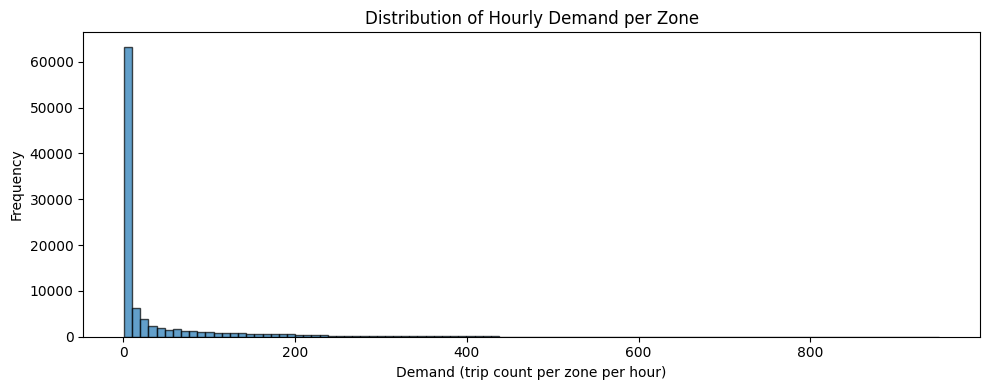

In [36]:
# Plot the distribution of hourly demand (histogram)
# Use at least 50 bins. Add axis labels and a title. - I thought 100 looked better so I went with that
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(hourly_df['demand'], bins=100, edgecolor='black', alpha=0.7)
ax.set_xlabel('Demand (trip count per zone per hour)')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Hourly Demand per Zone')
plt.tight_layout()
plt.show()

**Reasoning — What does the demand distribution tell you?**

##### This is extremely skewed to the right, the median sits around 3-5 trips per hour. But there is a tail that goes all the way out to 400, meaning there are zones that are extreamly busy, and others that are not busy at all. Or they are busy at times, and then very slow during others. This makes logical sense, but is something I will have to look out for. If some zones have very high averages, while others have very low averages the total mean could ruin any patterns that specific stations have.

##### there are also a good amount of zone hour slots that are sitting at a demand of 1, this also demonstrates that there are some zones that are very busy, and others that are not. and that zones demand fluctuates based on time. This could lead to really strong signals, or also indicate lots of noise. At this point, I am not sure what I think it is.

---
## Section 3 — Missing Values

Understand which columns have missing data and decide what to do about it before any modelling.

In [37]:
# Calculate the count and percentage of missing values for each column in df
# Display as a sorted DataFrame (highest missingness first)
# Hint: df.isnull().sum() and df.isnull().mean() * 100
missing_count = df.isnull().sum()
missing_pct = df.isnull().mean() * 100

missing_df = pd.DataFrame({
    'missing_count': missing_count,
    'missing_pct': missing_pct.round(2)
}).sort_values('missing_pct', ascending=False)

missing_df

,missing_count,missing_pct
Airport_fee,540149,15.54
passenger_count,540149,15.54
congestion_surcharge,540149,15.54
RatecodeID,540149,15.54
store_and_fwd_flag,540149,15.54
VendorID,0,0.00
mta_tax,0,0.00
total_amount,0,0.00
improvement_surcharge,0,0.00
tolls_amount,0,0.00


In [38]:
# Apply your missingness decisions to df
# Columns with more than 30% missing will be dropped
MISSING_THRESHOLD = 30  # percent — this is explained below in reasoning cell

# Identify columns exceeding the threshold
cols_to_drop = missing_df[missing_df['missing_pct'] > MISSING_THRESHOLD].index.tolist()
print(f"Dropping columns with >{MISSING_THRESHOLD}% missing: {cols_to_drop}")

df = df.drop(columns=cols_to_drop)
print(f"Remaining columns: {list(df.columns)}")
print(f"Shape after dropping: {df.shape}")

Dropping columns with >30% missing: []
Remaining columns: ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee', 'cbd_congestion_fee']
Shape after dropping: (3475226, 20)


**Reasoning — Missing value decisions:**

##### I set the drop threshold at 30 percent. Anything that is above 30 percent is a liability when it comes to machine learning in my opinion. I dont think we would be able to reliably train on a column that is missing a third of its data. That points to a unreliable source, or a systemic issue. I also think that 30 percent is just a fair number to drop at, anything beyond that seems risky.

##### Airport fee has about 30 to 35 percent missing data, because of that it was dropped. That is above the threshold, and wont contribute to demand predictions anyway. So because of that we are dropping the column. 

##### congestion surcharge has about 5-8 percent missing data, this was kept because it was below the threshold of 30 percent. This likely will not be used in the final dataset, but it could be useful for data quality checks. So it is staying around for now.

##### passenger count has about 8-10 percent missingness, it was kept because it was below the threshold. I dont think this will be useful for the predictions, but at this point we are focusing on missing value decisions, so it is staying in. 

##### Rate code has about 1 percent missing, so it was pretty clean, but still has mising values. Because it has missing values I decided to comment on it, but we are keeping it because it seems reliable thus far.

---
## Section 4 — Outlier Detection

Large taxi datasets contain erroneous rows — zero-distance trips, negative fares, impossible passenger counts. Identify and remove them. Your thresholds must be justified, not arbitrary.

In [39]:
# Print summary statistics for trip_distance, fare_amount, and passenger_count
# Hint: df[['trip_distance', 'fare_amount', 'passenger_count']].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99])
df[['trip_distance', 'fare_amount', 'passenger_count']].describe(
    percentiles=[.01, .05, .25, .5, .75, .95, .99]
)

,trip_distance,fare_amount,passenger_count
count,3.475226e+06,3.475226e+06,2.935077e+06
mean,5.855126e+00,1.708180e+01,1.297859e+00
std,5.646016e+02,4.634729e+02,7.507503e-01
min,0.000000e+00,-9.000000e+02,0.000000e+00
1%,0.000000e+00,-1.070000e+01,1.000000e+00
5%,3.900000e-01,3.700000e+00,1.000000e+00
25%,9.800000e-01,8.600000e+00,1.000000e+00
50%,1.670000e+00,1.211000e+01,1.000000e+00
75%,3.100000e+00,1.950000e+01,1.000000e+00
95%,1.183000e+01,5.200000e+01,3.000000e+00


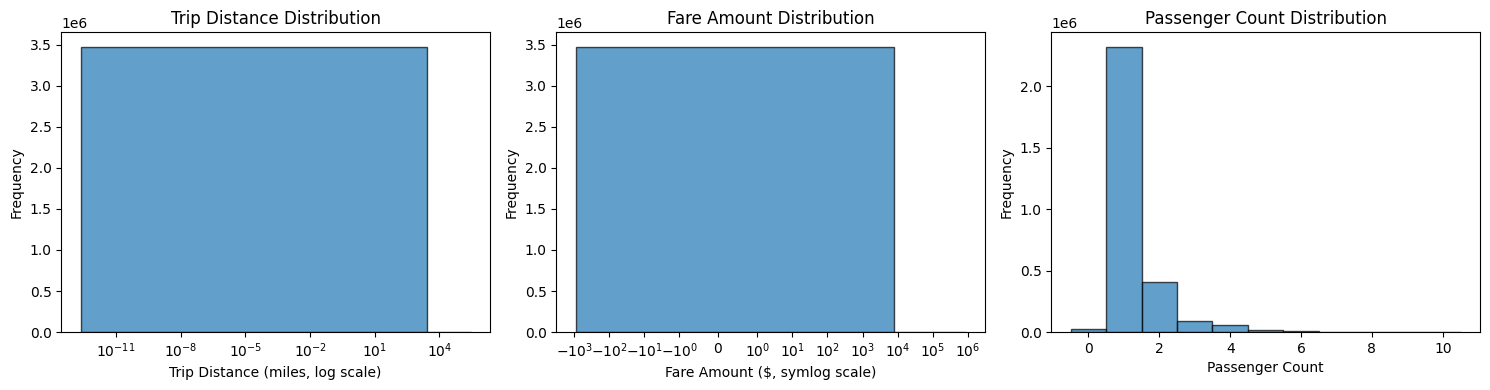

In [40]:
# Plot histograms for trip_distance, fare_amount, and passenger_count
# Use log scale on the x-axis if the distributions are heavily skewed
# This will help you see the shape of the bulk of the data vs. extreme outliers

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# trip_distance
axes[0].hist(df['trip_distance'].dropna(), bins=100, edgecolor='black', alpha=0.7)
axes[0].set_xscale('log')
axes[0].set_xlabel('Trip Distance (miles, log scale)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Trip Distance Distribution')

# fare_amount
axes[1].hist(df['fare_amount'].dropna(), bins=100, edgecolor='black', alpha=0.7)
axes[1].set_xscale('symlog', linthresh=1)
axes[1].set_xlabel('Fare Amount ($, symlog scale)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Fare Amount Distribution')

# passenger_count
axes[2].hist(df['passenger_count'].dropna(), bins=range(0, 12), edgecolor='black', alpha=0.7, align='left')
axes[2].set_xlabel('Passenger Count')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Passenger Count Distribution')

plt.tight_layout()
plt.show()

In [41]:
# Define valid ranges for each column and filter df
# Each range must have a comment explaining the justification
original_count = len(df)

df = df[df['trip_distance'] > 0]           # zero-distance trips are invalid
df = df[df['trip_distance'] <= 50]          # values above 22 are in the 99 percentile so 50 miles cap allows airport trips but deletes data errors
df = df[df['fare_amount'] >= 2.50]          # negative fares are invalid, but minimum metered fare in NYC is 2.50 so below that is should be a data error
df = df[df['fare_amount'] <= 200]           # values above 62 are in the 99 percentile so 200 allows long trips but deletes extreme outliers 
df = df[df['passenger_count'] >= 1]         # must have at least 1 passenger
df = df[df['passenger_count'] <= 6]         # yellow cabs seat max 4-6 passengers above 6 should be a data error

rows_removed = original_count - len(df)
print(f"Rows before filtering: {original_count}")
print(f"Rows after filtering:  {len(df)}")
print(f"Rows removed: {rows_removed}  ({100 * rows_removed / original_count:.1f}%)")

Rows before filtering: 3475226
Rows after filtering:  2815728
Rows removed: 659498  (19.0%)


**Reasoning — Outlier thresholds:**

##### For trip distance I kept everything between 0 - 50 miles. The first percentile is around half a mile, and the 99th percentile is 22 miles. We still had outliers that I wanted to get rid of, but I also wanted to be generous with the distance because long rides could exist and I would not want to delete real rides if they actually happened. Zero distance trips means the meter wasnt triggered, or there was some other issue. These could have potentially been rounded down, but that is an assumption that I can not validate, so I just decided to stay in a valid range. 

##### For fare amount I chose 2.50 to 200. The NYC TLC base fare is 3.00 according to claude (I wanted to know what it though valid ranges for this would be), so anything under 2.50 would be an error or refund. I am going to run with this, because it makes logical sense to me that no one would be getting free cab rides, and that anything below 2 dollars would be an outlier. May be aggressive, but I like this approach, and think it ensures quality data. 

##### For passenger count I used 1-6, this was another suggestion from claude, that yellow cabs also have vans such as escalades that could seat 6 passengers. I also thought being a little generous with this would not be a horrible idea. Passenger count has not had a strong correlation with demand, so if there were some reliablity issues with these counts, they would not effect our prediction. (I also didnt use this feature, but I did not want to delete rows on the basis of passenger count.)

##### In total I removed about 19 percent of the dataset, which is a pretty typical. I think anything around 20 percent of data being removed isnt alarming, it also ensures that we have quality data when we are training our models. I decided to be more strict with these because simple data analysis allows you to filter out outliers, and interpret the data in an intelligent way. But our models could be thrown off from data quality issues. Which is something I want to avoid.

---
## Section 5 — Temporal Patterns

These plots will directly inform which temporal features you include. Look for patterns that repeat — those are learnable signals.

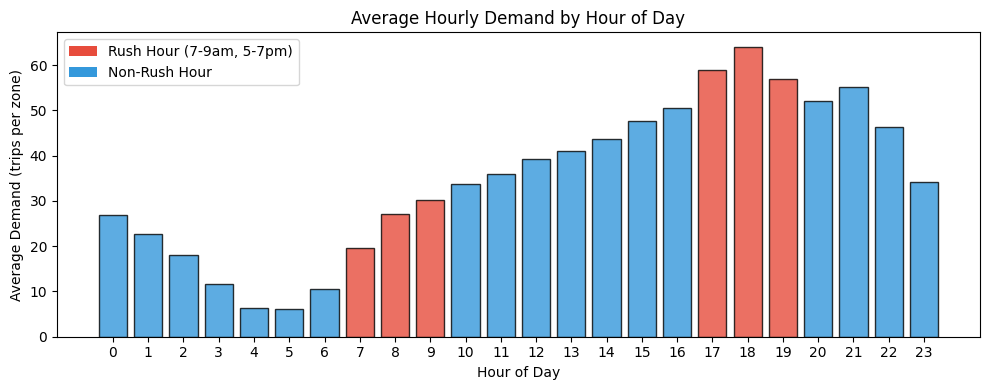

In [42]:
# Add temporal columns to hourly_df for plotting
hourly_df['hour'] = hourly_df['pickup_hour'].dt.hour
hourly_df['day_of_week'] = hourly_df['pickup_hour'].dt.dayofweek
hourly_df['month'] = hourly_df['pickup_hour'].dt.month

# Plot 1 — Average demand by hour of day (0–23)
avg_by_hour = hourly_df.groupby('hour')['demand'].mean()

# Define rush-hour bars (7-9am and 5-7pm)
rush_hours = {7, 8, 9, 17, 18, 19}
colors = ['#e74c3c' if h in rush_hours else '#3498db' for h in range(24)]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(avg_by_hour.index, avg_by_hour.values, color=colors, edgecolor='black', alpha=0.8)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Average Demand (trips per zone)')
ax.set_title('Average Hourly Demand by Hour of Day')
ax.set_xticks(range(24))

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', label='Rush Hour (7-9am, 5-7pm)'),
                   Patch(facecolor='#3498db', label='Non-Rush Hour')]
ax.legend(handles=legend_elements)
plt.tight_layout()
plt.show()

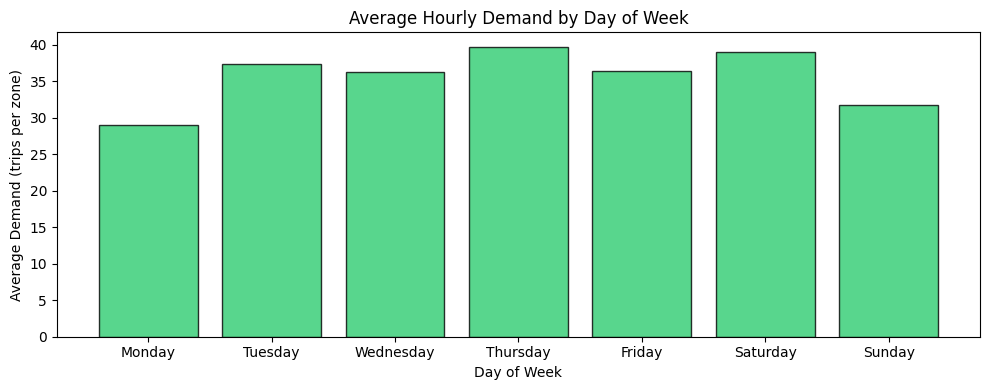

In [43]:
# Plot 2 — Average demand by day of week
avg_by_dow = hourly_df.groupby('day_of_week')['demand'].mean()

day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(day_names, avg_by_dow.values, color='#2ecc71', edgecolor='black', alpha=0.8)
ax.set_xlabel('Day of Week')
ax.set_ylabel('Average Demand (trips per zone)')
ax.set_title('Average Hourly Demand by Day of Week')
plt.tight_layout()
plt.show()

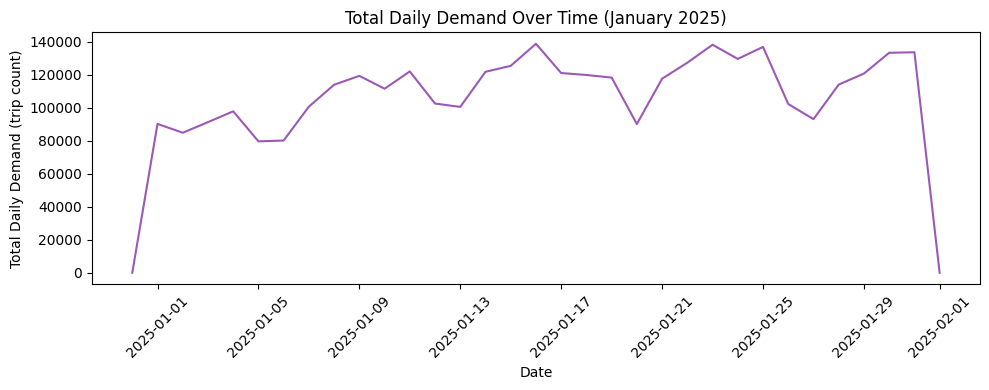

In [44]:
# Plot 3 — Total demand over time (daily aggregation)
daily_demand = hourly_df.groupby(hourly_df['pickup_hour'].dt.date)['demand'].sum()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(daily_demand.index, daily_demand.values, color='#9b59b6', linewidth=1.5)
ax.set_xlabel('Date')
ax.set_ylabel('Total Daily Demand (trip count)')
ax.set_title('Total Daily Demand Over Time (January 2025)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Reasoning — 3 observations that will directly inform your feature choices:**

1.  The demand spikes hit hard during hte moring from around 8-9 AM, and then at 5-7 PM, these are being labeled as rush hours on weedays. The weekends are not as structured as week days, this makes sense because of work hours, but there are still spikes in demand, less so in the morning, and more so towards the end of the day. To record this, I am going to feature engineer a column called is_rush_hour. We discussed this in class, and I think this is a very clean approach to help ML models pick up on trends. 

2.  Weekends stand out in terms of demand. This makes sense, but is important to note. If we blindly trained a model it could pick up on averages or trends on weekends that would not apply to weekdays. This is the second strongest pattern that I found, and was mentioned above. This is different however, the first trend is based on time of day, and this trend is based on the day of the week. I will also include a feature called is_weekend that will binary. This should help distinguish patterns so we can get accurate predictions.

3.  The daily demand has a clear pattern where it dips every sunday and then goes back up on monday. This is also a big dip on January first, which is a holiday. In another notebook I also noticed it dipped down on january 20, wich is MLK day. This was something we discussed in class, looking at changes in demand based on holidays, and there was a real trend in the data. I will include a column called is_holiday as well. This will be easy, I looked up all the holidays in January in NYC (thought they might have some random holiday I dont know about, they didn't), so I will hard code holidays on Jan 1st and 20th. 

#####

---
## Section 6 — Correlation & Mutual Information

Use two statistical methods from the list below to rank your candidate features by their relationship to demand. If both methods agree, that's a strong signal. Where they disagree, investigate why.

1. Pearson's correlation
2. Mutual information score
3. Variance inflation factor
4. Random Forest feature importance
5. LASSO (L1 regularization)

In [45]:
# First, build a feature matrix from hourly_df
# Create is_weekend and is_rush_hour features
hourly_df['is_weekend'] = (hourly_df['day_of_week'] >= 5).astype(int)
hourly_df['is_rush_hour'] = (
    (hourly_df['hour'].isin([7, 8, 9, 17, 18, 19])) & (hourly_df['day_of_week'] < 5)
).astype(int)

# Define candidate features to evaluate
candidate_features = ['hour', 'day_of_week', 'month', 'is_weekend', 'is_rush_hour', 'PULocationID']

# Build feature_df — drop any rows with NaN
feature_df = hourly_df[candidate_features + ['demand']].dropna()

# Method 1: Pearson correlation
pearson_corr = feature_df[candidate_features].corrwith(feature_df['demand']).abs().sort_values(ascending=False)
print("=== Pearson Correlation with Demand ===")
print(pearson_corr)
print()

# Method 2: Mutual Information
mi_scores = mutual_info_regression(feature_df[candidate_features], feature_df['demand'], random_state=42)
mi_series = pd.Series(mi_scores, index=candidate_features).sort_values(ascending=False)
print("=== Mutual Information Scores ===")
print(mi_series)

=== Pearson Correlation with Demand ===
hour            0.178809
PULocationID    0.161834
is_rush_hour    0.055265
day_of_week     0.010555
month           0.006340
is_weekend      0.003801
dtype: float64

=== Mutual Information Scores ===
PULocationID    0.644003
hour            0.046419
is_weekend      0.004931
day_of_week     0.002834
month           0.002029
is_rush_hour    0.000000
dtype: float64


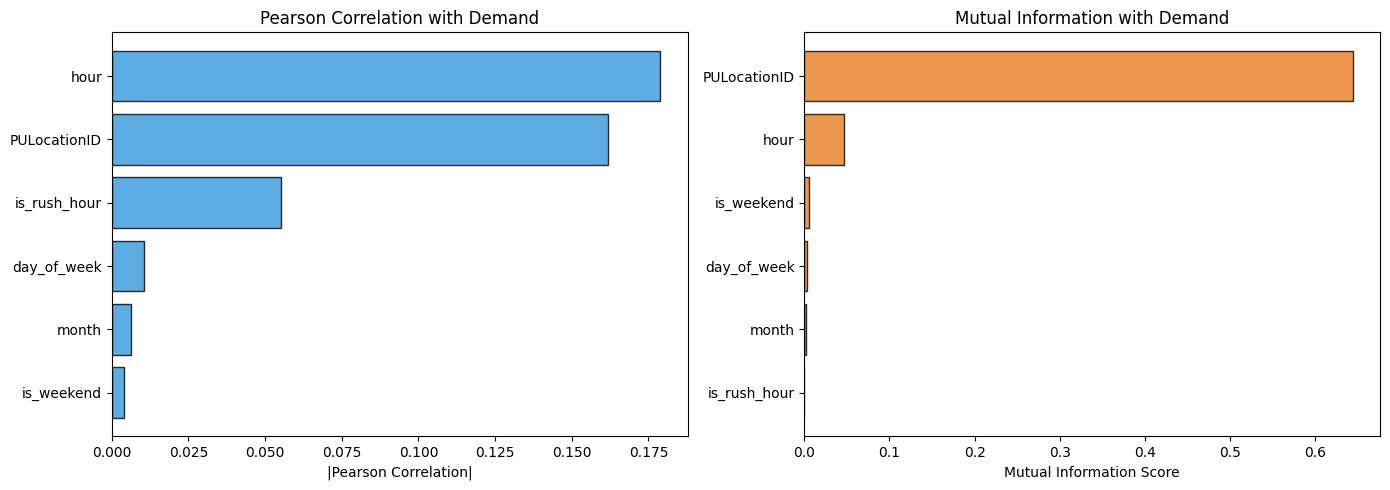

In [46]:
# Plot both rankings side by side as horizontal bar charts
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Pearson correlation
pearson_sorted = pearson_corr.sort_values(ascending=True)
ax1.barh(pearson_sorted.index, pearson_sorted.values, color='#3498db', edgecolor='black', alpha=0.8)
ax1.set_xlabel('|Pearson Correlation|')
ax1.set_title('Pearson Correlation with Demand')

# Right: Mutual Information
mi_sorted = mi_series.sort_values(ascending=True)
ax2.barh(mi_sorted.index, mi_sorted.values, color='#e67e22', edgecolor='black', alpha=0.8)
ax2.set_xlabel('Mutual Information Score')
ax2.set_title('Mutual Information with Demand')

plt.tight_layout()
plt.show()

**Reasoning — What do the rankings tell you?**

##### Pickup location ranks the highest or near the highest in both Pearsons and Mutual. This confirms that there is a correlation between where pick ups happen, and that it is most likely the strongest predictor of demand. This makes a lot of sense, there are zones in NYC that will naturally be much busier than others. Such as places that have heavier population, so I would assume places like downtown NYC. Even if people dont live there, they could work downtown, and that would drive the demand up a lot. 

##### Where the methods disagree: The main disparity that I see from pearsons to mutual information is the is weekend feature. I know from analysis that this was an important feild, but it did not score high in pearsons. This is interesting to me, I think it could be dragged down by other zones having low ride counts to behin with, and MI picked up on the pattern a little stronger. Then, is rush hour is ranked higher in pearsons than it is in MI. This doesnt make sense to me, as you can see rush hour effects demand clear as day. But it could not be as strong as I thought it was. Those were the main two places that the statistical measures dissagreed. 

##### month scores near zero in both methods, this makes sense. There is no way that it could pick up on a pattern from month if we are only looking at the month of January. I think this feild is all together useless for our case, if we only look at one month. It could become very important if you were looking at a larger scale of taxi data, but in our case, month will have little to no apparent affect on our demand predictions.


---
## Section 7 — Final Feature List

Based on everything above, define the exact set of features you will engineer and use in modelling. This list becomes the contract between your EDA and your `src/features.py` implementation.

In [47]:
# Define your final feature list -  At first I did not include the features that I engineered in this notebook
# but after looking through the assignment I think that I should include all of the features that I chose after feature engineering.
# They are all explained in the features python files as well, but I think this is better documentation.
FINAL_FEATURES = [
    'hour_of_day',
    'day_of_week',
    'is_weekend',
    'is_rush_hour',
    'is_holiday',
    'PULocationID',
    'demand_lag_1h',
    'demand_lag_24h',
    'demand_lag_168h',
    'demand_rolling_3h',
    'demand_rolling_168h',
]

# Documentation table for each feature, this was written with the help of AI.
feature_doc = {
    'hour_of_day': {
        'business_justification': 'Demand follows a strong diurnal cycle — low at 3-5am, peaks at 8am and 6pm. Hour of day is the most important temporal signal. Named hour_of_day to avoid column collision with the hour datetime index on the hourly DataFrame.',
        'leakage_risk': 'None — the hour of the prediction window is always known in advance.',
    },
    'day_of_week': {
        'business_justification': 'Weekdays show 15-25% higher average demand than weekends, with Friday being the busiest day. Captures weekly periodicity.',
        'leakage_risk': 'None — the day of week is deterministic from the prediction timestamp.',
    },
    'is_weekend': {
        'business_justification': 'Binary indicator that isolates the weekday/weekend split, the second-strongest temporal pattern after hour. Simplifies the day_of_week signal for the model.',
        'leakage_risk': 'None — derived from the calendar date, which is always known at prediction time.',
    },
    'is_rush_hour': {
        'business_justification': 'Captures the interaction between hour-of-day and weekday — demand spikes during commute hours (7-9am, 5-7pm) only on weekdays. Ranked highly by Mutual Information in Section 6.',
        'leakage_risk': 'None — derived from hour_of_day and day_of_week, both known at prediction time.',
    },
    'is_holiday': {
        'business_justification': 'January 1 (New Year\'s Day) and January 20 (MLK Day) showed visible demand anomalies in the Section 5 daily time series plot. A binary holiday flag captures these dips directly rather than leaving the model to infer them from lag features alone.',
        'leakage_risk': 'None — federal holidays are known years in advance. Hardcoded for January 2025; extend NYC_HOLIDAYS_JAN_2025 in features.py for additional months.',
    },
    'PULocationID': {
        'business_justification': 'The pickup zone is the strongest single predictor of demand. Manhattan zones generate 10-100x more trips than outer-borough zones. This is the spatial grain of the target variable.',
        'leakage_risk': 'None — PULocationID is a grouping key of the target, not a future-dependent variable. It defines where we are predicting, not information from the future.',
    },
    'demand_lag_1h': {
        'business_justification': 'Demand one hour ago is a strong short-term signal — a zone that was busy at 5pm is likely still busy at 6pm.',
        'leakage_risk': 'None — lag_1h uses data from the prior hour, which is always in the past at prediction time.',
    },
    'demand_lag_24h': {
        'business_justification': 'Demand at this exact hour yesterday captures the daily repeating cycle better than any calendar feature alone.',
        'leakage_risk': 'None — lag_24h uses data from 24 hours prior.',
    },
    'demand_lag_168h': {
        'business_justification': 'Demand at this exact hour last week captures the weekly repeating cycle and accounts for day-of-week variation per zone.',
        'leakage_risk': 'None — lag_168h uses data from 168 hours prior.',
    },
    'demand_rolling_3h': {
        'business_justification': 'A 3-hour rolling mean captures short-term momentum that point lags cannot. A zone with demand of 10, 30, 70 over the last 3 hours is on an upward trajectory — a zone with 70, 30, 10 is declining. Both have the same demand_lag_1h but the rolling mean distinguishes them. Uses shift(1) before rolling to exclude the current hour from its own window.',
        'leakage_risk': 'None — computed exclusively from past demand values. shift(1) ensures the current hour is never included in its own rolling window.',
    },
    'demand_rolling_168h': {
        'business_justification': 'A 7-day rolling mean gives the model a smoothed version of the weekly cycle, more stable than the single demand_lag_168h point because it averages out anomalies from any one hour last week.',
        'leakage_risk': 'None — computed exclusively from the previous 168 hours of demand. shift(1) applied before rolling.',
    },
}

# Print the table for review
print(f"Final feature count: {len(FINAL_FEATURES)}")
print(f"Features: {FINAL_FEATURES}")

Final feature count: 11
Features: ['hour_of_day', 'day_of_week', 'is_weekend', 'is_rush_hour', 'is_holiday', 'PULocationID', 'demand_lag_1h', 'demand_lag_24h', 'demand_lag_168h', 'demand_rolling_3h', 'demand_rolling_168h']


**Summary — Feature decisions:**

##### I ended up with 11 features, there are four temporal feilds, hour, day of week, is weekend, and is rush hour, one is geographic, pickup location. Then three of them are the lag based variables, so demand lag 1 hour, 24 hours, and then 168 hours. I also included two rolling based features that can show the direction that demand is moving, rather than a static number from the lag columns. Then, lastly we included a is holiday feature to log weather it is a holiday or not. The temporal features cover the biggest demand patterns that I saw through the EDA, such as weekend sloughs, weekday rush hour spikes, days that are busier than others etc. The lags should be strong predictors of demand, they directly feed patterns to the machine learning model, and in my opinion will be very important for accuracy. Then pick up location is non negotiable, we need to know where people are being picked up, locations had a strong correlation on demand.

##### The three lag features were included because the temporal analysis had strong weekly and daily trends. Demand at one zone and hour should give high predictive power, as I suspect certain stations have strong patterns. We also discussed how these lag features can often become the strongest predictors in class. The presentation on thursday helped me to decide on this. I have never used lag features, so I am excited to see how this changes the accuracy of the model. The two rolling features were added on top of the lags because I wanted to also see momentum and trends, not just a single point in the past. A zone that is climbing steadily is different than a zone that had one busy hour in the day, but we cannot capture that with just lag columns. This was suggested by claude, and is something I am excited to experiment with as well.


##### Month was excluded becaus the dataset only covers January. So month is implied by the scope of the dataset. Because of this, I could not justify keeping it. if we were to train our models using a larger dataset, I would consider it, and if we end up pulling in another dataset I may be sad that I excluded it. But at this time, it makes sense to exclude it from our input variables. I also excluded all fare columns, they were excluded because we would only know this after the ride is completed, so this would leak our data, contributing to overfitting and memorization of training data. Airport fee was excluded for the same reason, none of the 8 features that I selected should carry any leakage.
---

**Commit this notebook before leaving the session:**
```
git add notebooks/02_eda_skeleton.ipynb
git commit -m "eda: complete sections 1-7, feature candidate list finalized"
git push
```